<div style="font-family:verdana;"><span style="font-size:400%;"> <center>Module 1: ECDF and Rank-Based Tests</center> </span>
    
</div>

This notebook introduces three foundational nonparametric tools:

- the empirical cumulative distribution function (ECDF)
- the sign test
- the Mann-Whitney framework

The goals are:

1. implement and use basic nonparametric methods,
2. compare them with familiar parametric or library-based counterparts,
3. build intuition for what these methods estimate and why they matter



# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">Contents</p>

**<a href=#1.-Introduction>1. Introduction</a>**

**<a href=#2.-Empirical-CDF>2. Empirical CDF</a>**

**<a href=#3.-Sign-Test>3. Sign Test</a>**

**<a href=#4.-Mann-Whitney-Framework>4. Mann-Whitney Framework</a>**

**<a href=#5.-Conclusion>5. Conclusion</a>**

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">1. Introduction</p>

## 📙 Import libraries and modules

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from nonparametric_stats.ecdf import ecdf
from nonparametric_stats.rank_tests import sign_test, mann_whitney_pairwise_less

## ⚙️ Configuration

In [ ]:
rng = np.random.default_rng(42)

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">2. Empirical CDF</p>

The empirical cumulative distribution function is the most basic nonparametric estimator of a distribution function.

Given observations \(x_1, ... , x_n\), the ECDF at a point \(t\) is the proportion of sample points less than or equal to \(t\).

This makes it a natural first example of nonparametric estimation: we do not assume a normal, exponential, or other parametric family in order to estimate the distribution.

In [18]:
x = rng.exponential(scale=1.0, size=100)
xs, ys = ecdf(x)

ecdf_preview = pd.DataFrame({
    "x_sorted": xs[:10],
    "F_n(x)": ys[:10]
})

ecdf_preview

,x_sorted,F_n(x)
0,0.008129,0.01
1,0.028722,0.02
2,0.034437,0.03
3,0.090745,0.04
4,0.093132,0.05
5,0.106588,0.06
6,0.115136,0.07
7,0.126925,0.08
8,0.140270,0.09
9,0.150627,0.10


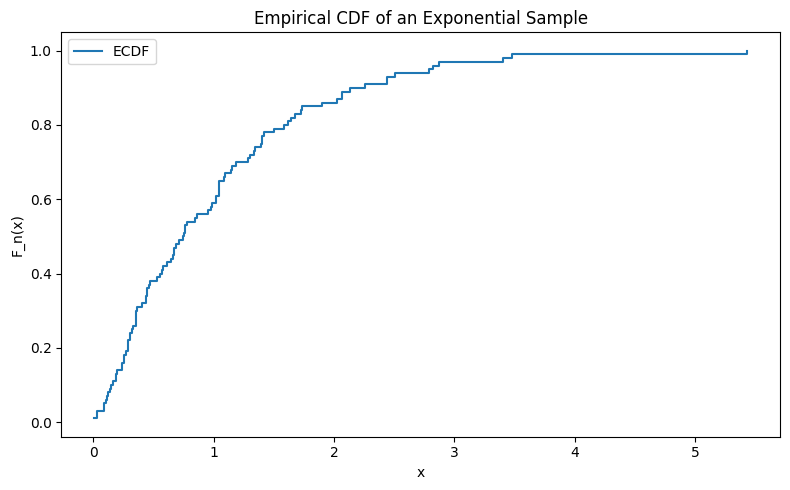

In [19]:
plt.figure(figsize=(8, 5))
plt.step(xs, ys, where="post", label="ECDF")
plt.xlabel("x")
plt.ylabel("F_n(x)")
plt.title("Empirical CDF of an Exponential Sample")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/ecdf_exponential_sample.png", dpi=150, bbox_inches="tight")
plt.show()

The ECDF is a step function that jumps upward by \(1/n\) at each observed data point.

Unlike a parametric estimator, it does not assume a particular family for the underlying distribution. It simply records the cumulative mass of the observed sample.

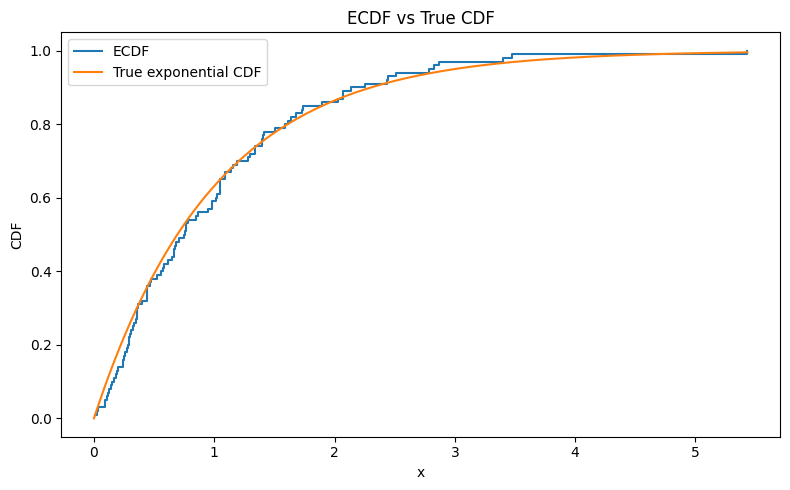

,quantity,value
0,Sample size,100.000000
1,Kolmogorov-style sup error,0.063016


In [20]:
grid = np.linspace(0, xs.max(), 500)
true_cdf = stats.expon.cdf(grid, scale=1.0)

ecdf_on_grid = np.interp(grid, xs, ys, left=0.0, right=1.0)
sup_error = np.max(np.abs(ecdf_on_grid - true_cdf))

plt.figure(figsize=(8, 5))
plt.step(xs, ys, where="post", label="ECDF")
plt.plot(grid, true_cdf, label="True exponential CDF")
plt.xlabel("x")
plt.ylabel("CDF")
plt.title("ECDF vs True CDF")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/ecdf_vs_true_cdf.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "quantity": ["Sample size", "Kolmogorov-style sup error"],
    "value": [len(x), sup_error]
})

The ECDF tracks the true CDF reasonably well, though it remains a step function and therefore differs from the smooth population curve.

The sup-norm discrepancy shown above is a useful way to summarize the largest vertical gap between the empirical and true distribution functions.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">3. Sign Test</p>

The sign test is a simple exact nonparametric procedure for testing whether a median difference is zero.

It uses only the signs of the observations or paired differences, discarding their magnitudes. This makes it less informative that a mean-based parametric procedure, but also more robust to outliers and heavy-tailed behavior.

In [22]:
diffs = rng.normal(loc=0.4, scale=1.0, size=20)

sign_result = sign_test(diffs)

sign_summary = pd.DataFrame({
    "quantity": ["Effective sample size", "Positive differences", "Two-sided p-value"],
    "value": [sign_result["n"], sign_result["n_pos"], sign_result["p_value"]]
})

sign_summary

,quantity,value
0,Effective sample size,20.000000
1,Positive differences,16.000000
2,Two-sided p-value,0.011818


In [23]:
ttest_result = stats.ttest_1samp(diffs, popmean=0.0)

comparison = pd.DataFrame({
    "method": ["Sign test", "One-sample t-test"],
    "statistic": [np.nan, ttest_result.statistic],
    "p_value": [sign_result["p_value"], ttest_result.pvalue]
})

comparison

,method,statistic,p_value
0,Sign test,NaN,0.011818
1,One-sample t-test,2.426536,0.025363


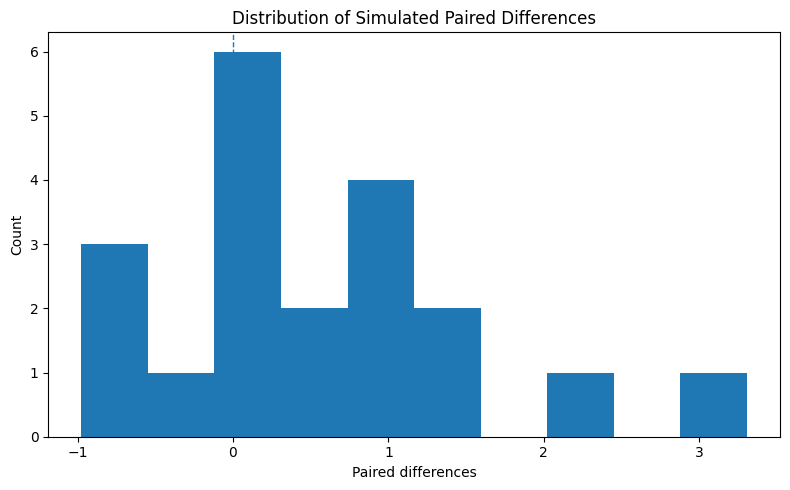

In [24]:
plt.figure(figsize=(8, 5))
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.hist(diffs, bins=10)
plt.xlabel("Paired differences")
plt.ylabel("Count")
plt.title("Distribution of Simulated Paired Differences")
plt.tight_layout()
plt.savefig("../reports/figures/sign_test_differences_hist.png", dpi=150, bbox_inches="tight")
plt.show()

The sign test and one-sample t-test are related but not identical.

The sign test asks whether the median difference appears to be zero, using only directional information. The t-test instead uses magnitudes and is tied to a mean-based parametric framework.

In settings where magnitudes are informative and distributional assumptions are reasonable, the t-test can be more powerful. In settings with outliers, skewness, or heavy tails, the sign test can be a useful robust alternative.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">4. Mann-Whitney Framework</p>

The Mann-Whitney procedure is often introduced as a nonparametric alternative to the two-sample t-test, but that description can hide its deeper interpretation.

A useful way to understand it is through pairwise comparisons: how often is a draw from one sample less than a draw from the other?

In [25]:
x = rng.normal(0.0, 1.0, size=30)
y = rng.normal(0.5, 1.0, size=35)

group_summary = pd.DataFrame({
    "group": ["x", "y"],
    "n": [len(x), len(y)],
    "mean": [np.mean(x), np.mean(y)],
    "median": [np.median(x), np.median(y)],
    "std": [np.std(x, ddof=1), np.std(y, ddof=1)]
})

group_summary

,group,n,mean,median,std
0,x,30,0.010228,0.052811,0.947969
1,y,35,0.733241,0.938993,1.027700


In [26]:
pairwise_less = mann_whitney_pairwise_less(x, y)
u_scipy = stats.mannwhitneyu(x, y, alternative="two-sided").statistic
prob_x_less_y = pairwise_less / (len(x) * len(y))

mw_summary = pd.DataFrame({
    "quantity": [
        "Pairwise less-than count",
        "SciPy U for x",
        "Estimated P(X < Y)"
    ],
    "value": [
        pairwise_less,
        u_scipy,
        prob_x_less_y
    ]
})

mw_summary

,quantity,value
0,Pairwise less-than count,735.0
1,SciPy U for x,315.0
2,Estimated P(X < Y),0.7


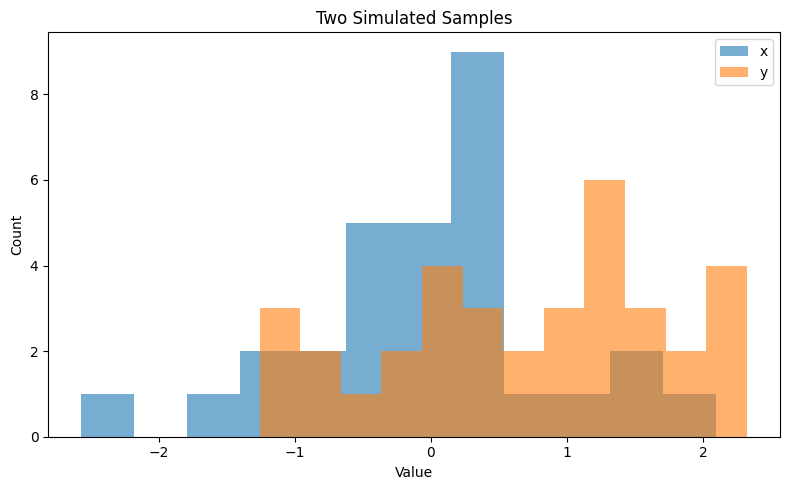

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(x, bins=12, alpha=0.6, label="x")
plt.hist(y, bins=12, alpha=0.6, label="y")
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Two Simulated Samples")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/mann_whitney_group_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

The pairwise comparison count gives a probability-style interpretation of the Mann–Whitney framework.

Dividing by \(nm\) estimates the probability that a random draw from sample \(X\) is less than a random draw from sample \(Y\). This is often more intuitive than thinking of the method only as a rank-based replacement for the two-sample t-test.

The SciPy statistic and the pairwise-less count are related, but they are not the same quantity. The SciPy output is the conventional \(U\) statistic for the first sample.

In [28]:
final_summary = pd.DataFrame({
    "method": ["ECDF", "Sign test", "Mann–Whitney framework"],
    "main idea": [
        "Estimate a distribution function without a parametric family",
        "Test whether a median difference is zero using only signs",
        "Compare two samples through ranks or pairwise ordering"
    ],
    "nonparametric feature": [
        "No fixed distributional form assumed",
        "Uses directional information only",
        "Based on ordering rather than mean/variance structure"
    ]
})

final_summary

,method,main idea,nonparametric feature
0,ECDF,Estimate a distribution function without a par...,No fixed distributional form assumed
1,Sign test,Test whether a median difference is zero using...,Uses directional information only
2,Mann–Whitney framework,Compare two samples through ranks or pairwise ...,Based on ordering rather than mean/variance st...


# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">5. Conclusion</p>

This notebook introduced three basic nonparametric tools.

- The ECDF is the canonical nonparametric estimator of a distribution function.
- The sign test shows how valid inference can be built from signs alone.
- The Mann–Whitney framework can be understood through pairwise ordering probabilities, not only as a rank-based test.

Together, these examples show the central theme of nonparametric statistics: useful estimation and inference can often be done with much weaker structural assumptions than in classical parametric modeling.